# <font color='blue'> The Perceptron </font>

The McCulloch–Pitts neuron demonstrated that simple computational units could perform logical operations by combining weighted inputs with a threshold function. However, the weights in this model were fixed and had to be chosen manually. In practical machine learning, the ability to **learn** these weights automatically from data is essential.

In 1958, Frank Rosenblatt introduced the **Perceptron**, the first artificial neuron capable of learning from labelled examples. The perceptron is a supervised learning algorithm designed for binary classification. During training, it iteratively adjusts its weights whenever it makes an incorrect prediction, gradually improving its ability to separate the two classes.

Although the perceptron can only solve linearly separable problems, it established the foundations of trainable neural networks and remains one of the most influential models in the history of machine learning.

---



## <font color='orange'> From Fixed Rules to Learning </font>

The McCulloch–Pitts neuron followed

```
Inputs

↓

Fixed Weights

↓

Threshold

↓

Output
```

The perceptron replaces the fixed weights with **learnable parameters**. Conceptually,

```
Training Data

↓

Learn Weights

↓

Prediction
```

This simple idea transformed neural networks from manually designed systems into learning algorithms.

---



## <font color='orange'> The Perceptron Architecture </font>

A perceptron consists of

* input features,
* weights,
* a bias,
* an activation function.

Conceptually,

```
x₁ ---- w₁ \

x₂ ---- w₂  > Weighted Sum

⋮             +

xₙ ---- wₙ /

            ↓

        Activation

            ↓

         Prediction
```

Despite its simplicity,

this architecture remains the basic building block of modern neural networks.

---



## <font color='orange'> Mathematical Formulation </font>

The perceptron first computes the weighted sum

$$
\boxed{
z=
\sum_{i=1}^{n}
w_i x_i
+b
}
$$

or equivalently

$$
\boxed{
z=\mathbf{w}^T\mathbf{x}+b
}
$$

where

* \(\mathbf{x}\) is the input vector,
* \(\mathbf{w}\) is the weight vector,
* \(b\) is the bias.

This is identical to the computation performed by a modern artificial neuron.

---



## <font color='orange'> The Step Activation Function </font>

The original perceptron uses a **step function** to produce binary predictions.

$$
\boxed{
f(z)=
\begin{cases}
1,&z\ge0\\
0,&z<0
\end{cases}
}
$$

Thus, the perceptron predicts either

```
Class 0
```

or

```
Class 1.
```

Unlike modern neural networks, the perceptron produces only discrete outputs.

---



## <font color='orange'> Binary Classification </font>

The perceptron is designed for

binary classification.

Examples include

* Spam / Not Spam
* Fraud / Legitimate
* Signal / Background
* Disease / Healthy

Its objective is to learn a decision rule that separates the two classes.

---



## <font color='orange'> Decision Boundary </font>

The equation

$$
\mathbf{w}^T\mathbf{x}+b=0
$$

defines the **decision boundary**. For two input variables, this boundary is a straight line. For three input variables, it becomes a plane. In higher dimensions, it is called a **hyperplane**. Conceptually,

```
Class A

********

-----------

oooooooo

Class B
```

The perceptron learns the position and orientation of this boundary.

---



## <font color='orange'> The Learning Algorithm </font>

Training proceeds iteratively. For every training example, the perceptron

1. computes a prediction,
2. compares it with the true label,
3. updates the weights if the prediction is incorrect.

Conceptually,

```
Input

↓

Prediction

↓

Correct?

↓

No

↓

Update Weights

↓

Repeat
```

This continues until convergence or until a maximum number of iterations is reached.

---



## <font color='orange'> Weight Update Rule </font>

Suppose

* $y$ is the true label,
* $\hat{y}$ is the prediction,
* $\eta$ is the learning rate.

The perceptron updates its weights according to

$$
\boxed{
\mathbf{w}
\leftarrow
\mathbf{w}
+
\eta
(y-\hat{y})
\mathbf{x}
}
$$

The bias is updated similarly:

$$
\boxed{
b
\leftarrow
b
+
\eta
(y-\hat{y})
}
$$

Interpretation:

- If the prediction is correct, then $y-\hat{y}=0$, so no update is made.
- If the prediction is incorrect, the weights are adjusted to reduce the error on that example.

---



## <font color='orange'> The Role of the Learning Rate </font>

The parameter

$\eta$

controls the size of each update.

* Small learning rate:
  * slow learning,
  * stable updates.

* Large learning rate:
  * faster learning,
  * risk of unstable behaviour or oscillations.

Choosing an appropriate learning rate is an important aspect of neural network training.

---



## <font color='orange'> Convergence </font>

One of the most important theoretical results is the

**Perceptron Convergence Theorem**.

It states that

> If the training data are **linearly separable**, the perceptron learning algorithm will converge to a separating hyperplane after a finite number of updates.

However, if the data are **not** linearly separable, the perceptron will never converge, instead continuing to update its weights indefinitely (or until training is stopped).

---



## <font color='orange'> Strengths and Limitations </font>

### <font color='violet'> Strengths </font>
The perceptron introduced several groundbreaking ideas.

* Learns automatically from data.
* Simple mathematical formulation.
* Efficient training algorithm.
* Foundation of modern neural networks.
* Suitable for linearly separable binary classification.

Historically,

it demonstrated that machines could learn decision boundaries directly from examples.

---

### <font color='violet'> Limitations </font>
The perceptron also has important limitations.

* Can learn only linear decision boundaries.
* Limited to binary classification in its original form.
* Uses a non-differentiable step activation function.
* Cannot solve nonlinearly separable problems.

The most famous limitation is the **XOR problem**.

---

# <font color='blue'> Binary Classification Using Perceptron </font>

## <font color='orange'> Simulate Dataset With Two Classes </font>

In [213]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [214]:
# generate the dataset
X, y = make_classification(n_samples=10000, n_features=2, n_informative=2, n_redundant=0,n_repeated=0, n_classes=2, random_state=42)

# split the data into test (20%) and train (80%) samples
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [215]:
# Check the shape and entries of the training features
print(np.shape(X_train))
print(np.unique(X_train))

(8000, 2)
[-5.04909067 -4.90461226 -4.73878736 ...  3.81095942  3.84413723
  3.85313991]


In [216]:
# Check the shape and entries of the target variables
print(np.shape(y_train))
print(np.unique(y_train))

(8000,)
[0 1]


## <font color='orange'> Single Perceptron Classifier </font>

In [217]:
import numpy as np

### Function definitions for calculation weighted sum and activation

In [218]:
def weighted_sum(W, X, B):
    return np.dot(W, X) + B

def activation(W, X, B):
    z = weighted_sum(W, X, B)

    # use step-function for calculating activation
    return np.where(z >= 0, 1, 0)

### Perceptron Class Object

In [219]:
class perceptron:
    def __init__(self):
        # initialise the weights (2 element array) and biases as zeroes
        self.W = np.zeros(2)
        self.B = 0

    # method to predict the output
    def predict(self, X):
        return activation(self.W, X, self.B)

    # method to update the weights and bias
    def update(self, X, y, learning_rate):
        y_hat = activation(self.W, X, self.B)
        error = y - y_hat

        self.W = self.W + learning_rate*error*X
        self.B = self.B + learning_rate*error

### Training the Perceptron

In [220]:
# initialise perceptron
node = perceptron()

# number of epochs
epochs = 10

# training the perceptron
for _ in range(epochs):
    for i in range(len(X_train)):
        X_sample = X_train[i]       # features
        y_sample = y_train[i]       # target

        # use features, target and learning rate of 0.001
        node.update(X_sample, y_sample, 0.001)     

### Testing the Perceptron

In [221]:
pred_y = []

for X_sample in X_test:
    prob = node.predict(X_sample)
    pred_y.append(prob)

In [222]:
misclassified = (pred_y - y_test != 0).sum()
print(misclassified)

336


In [223]:
import pandas as pd

# Flatten the arrays to 1D and put them side-by-side
df = pd.DataFrame({
    'Predicted (pred_y)': np.array(pred_y).flatten(),
    'Actual (y_test)': np.array(y_test).flatten()
})

# Display the table (shows first and last few rows if long)
print(df.head(10))

   Predicted (pred_y)  Actual (y_test)
0                   1                1
1                   0                0
2                   0                0
3                   1                1
4                   0                0
5                   0                0
6                   1                1
7                   0                0
8                   1                1
9                   0                0


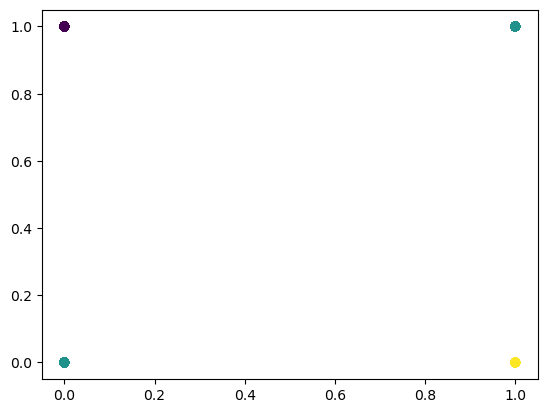

In [224]:
import matplotlib.pyplot as plt

plt.scatter(pred_y, y_test, c=pred_y-y_test)

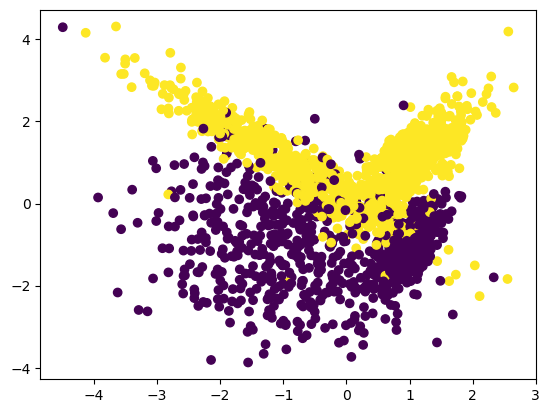

In [225]:
plt.scatter(X_test[:, 0], X_test[:,1], c=np.abs(y_test))

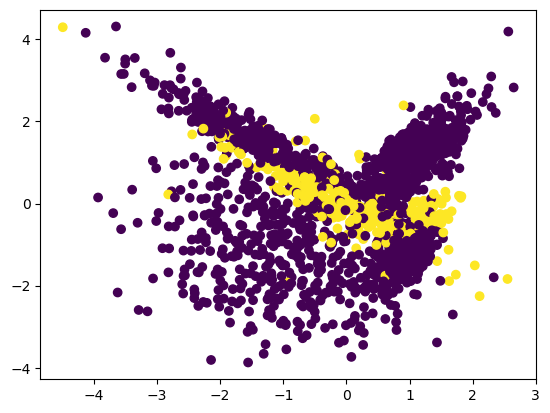

In [226]:
plt.scatter(X_test[:, 0], X_test[:,1], c=np.abs(pred_y-y_test))

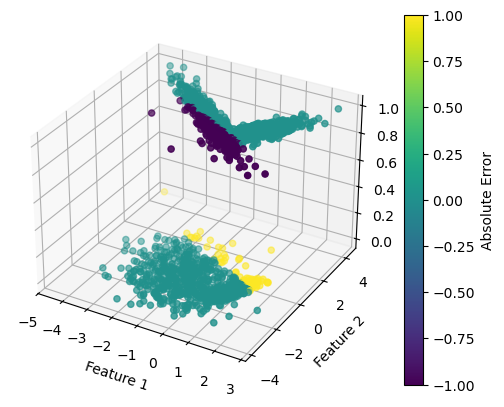

In [227]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

# Correct 3D plot: x, y, and z are explicitly plotted in 3D space
scatter = ax.scatter(X_test[:, 0], X_test[:, 1], y_test, c=(pred_y - y_test), cmap='viridis')

fig.colorbar(scatter, label="Absolute Error")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.set_zlabel("True Y Value (y_test)")
plt.show()


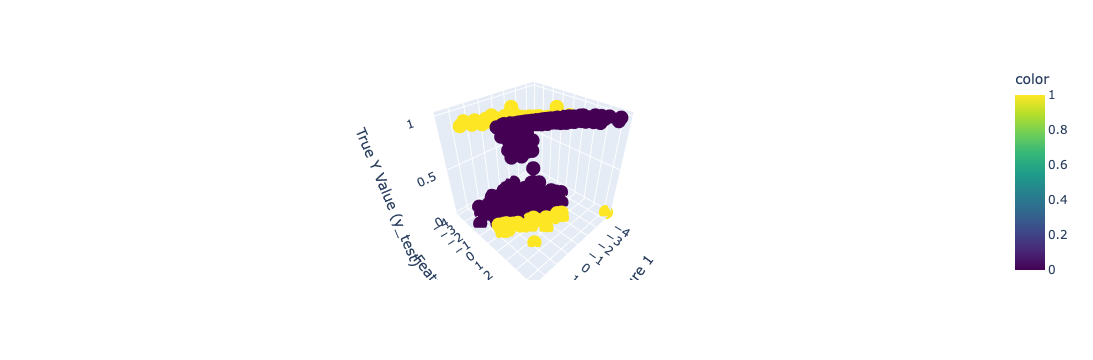

In [228]:
import numpy as np
import plotly.express as px

# Plotly replacement for your exact Matplotlib graph
fig = px.scatter_3d(
    x=X_test[:, 0],
    y=X_test[:, 1],
    z=y_test,
    color=np.abs(pred_y - y_test),
    color_continuous_scale='Viridis',
    labels={'x': 'Feature 1', 'y': 'Feature 2', 'z': 'True Y Value (y_test)'}
)

fig.show()


# <font color='blue'> The XOR Problem </font>

Consider the logical XOR function.

| Input 1 | Input 2 | XOR |
| :---: | :---: | :---: |
| 0 | 0 | 0 |
| 0 | 1 | 1 |
| 1 | 0 | 1 |
| 1 | 1 | 0 |

No single straight line can separate the two classes.

Consequently, a single-layer perceptron cannot learn XOR.

This limitation, highlighted by Marvin Minsky and Seymour Papert in 1969, led to a decline in neural network research for several years. The problem was later overcome through **multilayer neural networks** trained with **backpropagation**, which can represent nonlinear decision boundaries.

---



## <font color='orange'> Simulate Dataset With Two Classes </font>

In [229]:
from sklearn.datasets import make_moons

# 1. Generate a non-linearly separable dataset (like Moons or custom transformations)
X, y = make_moons(n_samples=2000, noise=0.15, random_state=42)

# Split the data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## <font color='orange'> Single Perceptron Classifier </font>

### Training the Perceptron

In [230]:
# initialise perceptron
node = perceptron()

# number of epochs
epochs = 10

# training the perceptron
for _ in range(epochs):
    for i in range(len(X_train)):
        X_sample = X_train[i]       # features
        y_sample = y_train[i]       # target

        # use features, target and learning rate of 0.001
        node.update(X_sample, y_sample, 0.001)     

### Testing the Perceptron

In [231]:
pred_y = []

for X_sample in X_test:
    prob = node.predict(X_sample)
    pred_y.append(prob)

In [232]:
misclassified = (pred_y - y_test != 0).sum()
print(misclassified)

52


In [233]:
import pandas as pd

# Flatten the arrays to 1D and put them side-by-side
df = pd.DataFrame({
    'Predicted (pred_y)': np.array(pred_y).flatten(),
    'Actual (y_test)': np.array(y_test).flatten()
})

# Display the table (shows first and last few rows if long)
print(df.head(10))

   Predicted (pred_y)  Actual (y_test)
0                   1                1
1                   1                1
2                   0                0
3                   1                1
4                   0                0
5                   1                1
6                   0                0
7                   0                0
8                   1                1
9                   1                1


### Visual Representation

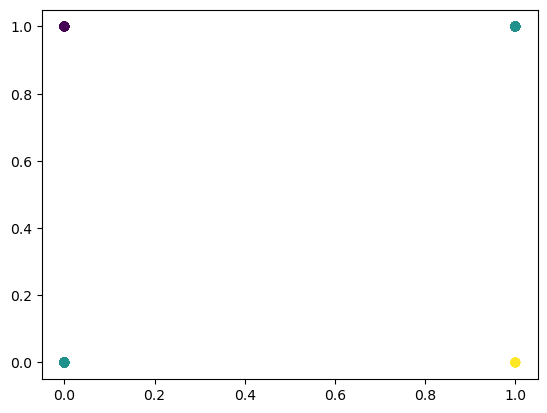

In [234]:
import matplotlib.pyplot as plt

plt.scatter(pred_y, y_test, c=pred_y-y_test)

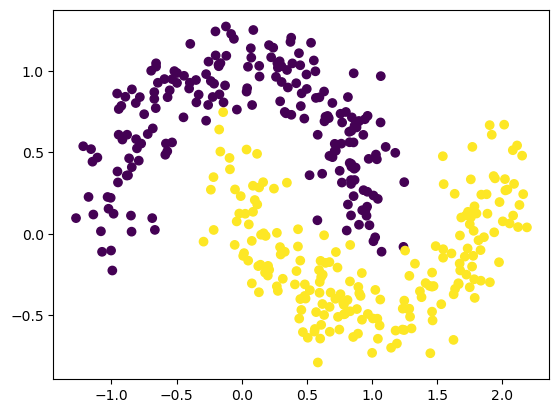

In [235]:
plt.scatter(X_test[:, 0], X_test[:,1], c=np.abs(y_test))

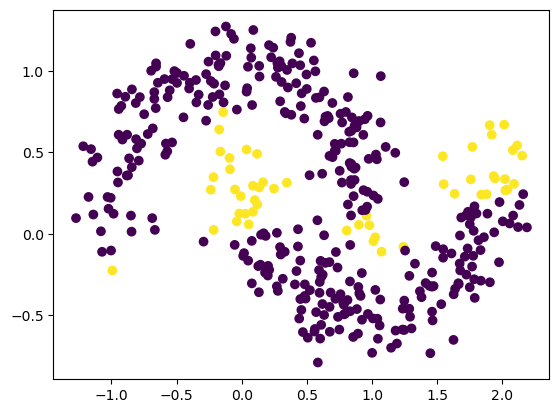

In [236]:
plt.scatter(X_test[:, 0], X_test[:,1], c=np.abs(pred_y-y_test))

# <font color='blue'> Binary Classification Using A Neuron </font>

## <font color='orange'> Non-linear Activation Function </font>

In [237]:
def weighted_sum(W, X, B):
    return np.dot(W, X) + B

def activation(W, X, B):
    z = weighted_sum(W, X, B)

    # calculating activation using non-linear activation
    activation = (1/(1+np.exp(-z)))
    return activation

### Neuron Class Object

In [238]:
class neuron:
    def __init__(self):
        # initialise the weights (2 element array) and biases as zeroes
        self.W = np.zeros(2)
        self.B = 0

    # method to predict the output
    def predict(self, X):
        return activation(self.W, X, self.B)

    # method to update the weights and bias
    def update(self, X, y, learning_rate):
        y_hat = activation(self.W, X, self.B)
        error = y - y_hat

        self.W = self.W + learning_rate*error*X
        self.B = self.B + learning_rate*error

### Training the Neuron

In [239]:
# initialise perceptron
node = neuron()

# number of epochs
epochs = 10

# training the perceptron
for _ in range(epochs):
    for i in range(len(X_train)):
        X_sample = X_train[i]       # features
        y_sample = y_train[i]       # target

        # use features, target and learning rate of 0.001
        node.update(X_sample, y_sample, 0.001)     

### Testing the Neuron

In [240]:
pred_y = []

for X_sample in X_test:
    prob = node.predict(X_sample)
    if prob > 0.5:
        pred_y.append(1)
    else:
        pred_y.append(0)

In [241]:
import pandas as pd

# Flatten the arrays to 1D and put them side-by-side
df = pd.DataFrame({
    'Predicted (pred_y)': np.array(pred_y).flatten(),
    'Actual (y_test)': np.array(y_test).flatten()
})

# Display the table (shows first and last few rows if long)
print(df.head(10))

   Predicted (pred_y)  Actual (y_test)
0                   1                1
1                   1                1
2                   0                0
3                   1                1
4                   1                0
5                   1                1
6                   0                0
7                   0                0
8                   1                1
9                   1                1


In [242]:
misclassified = (pred_y - y_test != 0).sum()
print(misclassified)

61


### Visual Representation

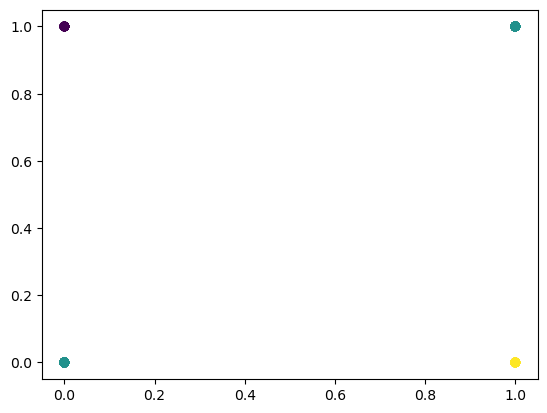

In [243]:
import matplotlib.pyplot as plt

plt.scatter(pred_y, y_test, c=pred_y-y_test)

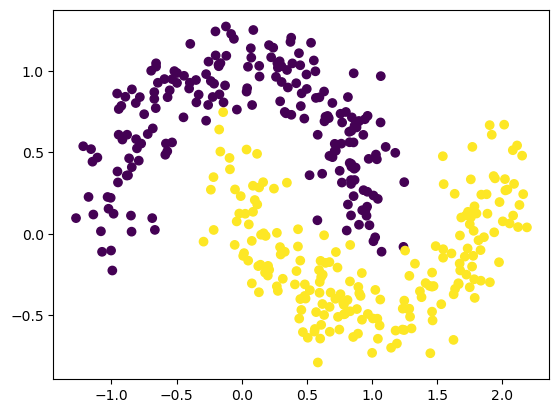

In [244]:
plt.scatter(X_test[:, 0], X_test[:,1], c=np.abs(y_test))

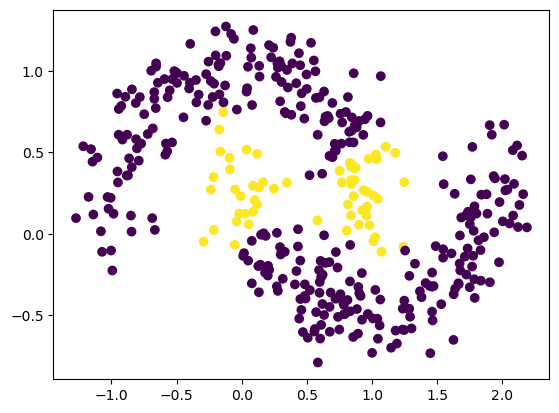

In [245]:
plt.scatter(X_test[:, 0], X_test[:,1], c=np.abs(pred_y-y_test))

# <font color='blue'> Classification Using Single Layer of Neurons </font>

In [19]:
import numpy as np

In [20]:
def weighted_sum(W, X, B):
    return np.dot(W,X) + B

In [21]:
def activation(W, X, B):
    z = weighted_sum(W, X, B)

    return 1/(1+np.exp(-z))

In [30]:
class neuron:
    def __init__(self):
        self.W = np.zeros(784)
        self.B = 0

    def predict(self, W, X, B):
        return activation(self.W, X, self.B)

    def update(self, X, y, learning_rate):
        y_hat = activation(self.W, X, self.B)
        error = y - y_hat

        self.W = self.W + learning_rate*error*X
        self.B = self.B + learning_rate*error

In [26]:
layer = np.array([neuron() for i in range(10)], dtype='object')

In [27]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

# Load the dataset (70,000 samples, 28x28 images flattened into 784 features)
X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False)

# Normalize the pixel data from [0, 255] to [0, 1]
X = X / 255.0

# Prepare the output
y_out = []
for output in y:
    y_arr = np.zeros(10)
    y_arr[int(output)] = 1
    y_out.append(y_arr)
    
# Split into Training (60,000) and Testing (10,000) sets
X_train, X_test, y_train, y_test = train_test_split(X, y_out, test_size=10000, random_state=42)

In [60]:
epochs = 10

for _ in range(epochs):
    for i in range(len(X_train)):
        x_sample = X_train[i]
        y_sample = y_train[i]
    
        for index, node in enumerate(layer):
            node.update(x_sample, y_sample[index], 0.001)

In [61]:
y_predicted = []

for x_sample in X_test:
    y_prob = []
    for node in layer:
        prob = node.predict(node.W, x_sample, node.B)
        y_prob.append(prob)
    y_predicted.append(y_prob)

num_err = 0
for y, y_hat in zip(y_test, np.round(y_predicted, 2)):
    
    if (np.argmax(y)-np.argmax(y_hat)) != 0:
        num_err += 1
    #print(np.argmax(y), np.argmax(y_hat))
print(num_err)
print(len(y_test))

854
10000


In [62]:
err = []
epoch = []

for epochs in range(25):
    for _ in range(epochs):
        for i in range(len(X_train)):
            x_sample = X_train[i]
            y_sample = y_train[i]
        
            for index, node in enumerate(layer):
                node.update(x_sample, y_sample[index], 0.001)
    
    y_predicted = []
    
    for x_sample in X_test:
        y_prob = []
        for node in layer:
            prob = node.predict(node.W, x_sample, node.B)
            y_prob.append(prob)
        y_predicted.append(y_prob)
    
    num_err = 0
    for y, y_hat in zip(y_test, np.round(y_predicted, 2)):
        
        if (np.argmax(y)-np.argmax(y_hat)) != 0:
            num_err += 1
        #print(np.argmax(y), np.argmax(y_hat))
    # print(num_err)
    # print(len(y_test))
    epoch.append(epochs)
    err.append(num_err)

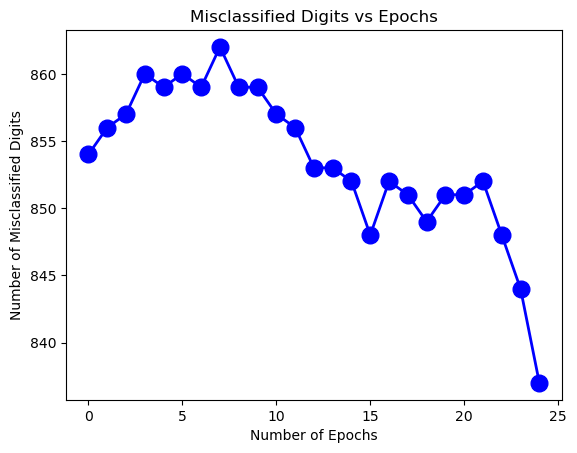

In [64]:
import matplotlib.pyplot as plt

plt.plot(epoch, err, color='blue', marker='o', linestyle='solid', linewidth=2, markersize=12)
plt.title('Misclassified Digits vs Epochs')
plt.xlabel('Number of Epochs')
plt.ylabel('Number of Misclassified Digits')
plt.show()